In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
train_data=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory=False) 
sample=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv") 
test_data=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv") 
print("TRAIN SHAPE", train_data.shape) 
print("Sample SHAPE", sample.shape) 
mean_val=train_data['TargetValue'].mean()
print("Mean Value: ", mean_val) 
sample['TargetValue']=mean_val 
path="/kaggle/working/submission.csv" 
sample.to_csv(path, index=False)
if os.path.exists(path):
    print("SUCCESS: submission.csv successfully generated in /kaggle/working!")
else:
    print("ERROR: File generation failed.")

TRAIN SHAPE (138701, 50)
Sample SHAPE (15000, 2)
Mean Value:  41521.87404705085
SUCCESS: submission.csv successfully generated in /kaggle/working!


In [3]:
print("\nTrain Data Summary Statistics:\n", train_data.describe())
print("\nTest Data Summary Statistics:\n", test_data.describe())


Train Data Summary Statistics:
        TransactionID    TargetValue       AssetID  ProductConfigID  \
count   1.387010e+05  138701.000000  1.387010e+05    138701.000000   
mean    2.186276e+06   41521.874047  1.204814e+06      7286.421922   
std     1.128497e+06   26361.125948  5.287376e+05      7542.421537   
min     1.139309e+06    7500.000000  8.000000e+00        39.000000   
25%     1.465754e+06   20500.000000  1.007930e+06      1693.000000   
50%     1.751884e+06   35000.000000  1.246956e+06      3852.000000   
75%     2.372139e+06   57000.000000  1.495817e+06     11873.000000   
max     6.333410e+06  142000.000000  2.478476e+06     37209.000000   

       ManufactureYear  OperationalHoursMeter  
count    138701.000000           8.205800e+04  
mean       1891.640853           4.553719e+03  
std         306.992001           2.792204e+04  
min        1001.000000           0.000000e+00  
25%        1990.000000           0.000000e+00  
50%        1998.000000           1.620000e+03  


In [4]:
print("\nTrain Data Missing Values:\n", train_data.isnull().sum())
print("\nTest Data Missing Values:\n", test_data.isnull().sum())


Train Data Missing Values:
 TransactionID                     0
TargetValue                       0
AssetID                           0
ProductConfigID                   0
DataOriginCode                    0
VendorPartnerID                   0
ManufactureYear                   0
OperationalHoursMeter         56643
UtilizationTier               88226
TransactionDate                   0
Spec_FullDescriptor               0
Spec_BaseClass                    0
Spec_SubClass                 36985
Spec_ReleaseSeries           105805
Spec_VariantModifier          86369
AssetScaleFactor              41210
FunctionalClassification          0
RegionCode                        0
InventoryGroupCategory            0
InventoryGroupDescription         0
col1                         104915
CabinType                         0
Forks                        109382
col3                         109448
col4                         128320
DrivetrainType                89956
col5                         128320

In [5]:
train_data=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory=False) 
sample=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv") 
test_data=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv") 
Target="TargetValue"
Id_col="TransactionID"
null = pd.DataFrame({'columns': train_data.columns, 'number of null values': train_data.isnull().sum().values})
null



,columns,number of null values
0,TransactionID,0
1,TargetValue,0
2,AssetID,0
3,ProductConfigID,0
4,DataOriginCode,0
5,VendorPartnerID,0
6,ManufactureYear,0
7,OperationalHoursMeter,56643
8,UtilizationTier,88226
9,TransactionDate,0


In [6]:
null_test=pd.DataFrame({'columns': test_data.columns, 'number of null values': test_data.isnull().sum().values})
null_test

,columns,number of null values
0,TransactionID,0
1,AssetID,0
2,ProductConfigID,0
3,DataOriginCode,0
4,VendorPartnerID,0
5,ManufactureYear,0
6,OperationalHoursMeter,6191
7,UtilizationTier,9644
8,TransactionDate,0
9,Spec_FullDescriptor,0


In [7]:
for index, row in null.iterrows():
    print(f"Column: {row['columns']} | Missing Count: {row['number of null values']}")

Column: TransactionID | Missing Count: 0
Column: TargetValue | Missing Count: 0
Column: AssetID | Missing Count: 0
Column: ProductConfigID | Missing Count: 0
Column: DataOriginCode | Missing Count: 0
Column: VendorPartnerID | Missing Count: 0
Column: ManufactureYear | Missing Count: 0
Column: OperationalHoursMeter | Missing Count: 56643
Column: UtilizationTier | Missing Count: 88226
Column: TransactionDate | Missing Count: 0
Column: Spec_FullDescriptor | Missing Count: 0
Column: Spec_BaseClass | Missing Count: 0
Column: Spec_SubClass | Missing Count: 36985
Column: Spec_ReleaseSeries | Missing Count: 105805
Column: Spec_VariantModifier | Missing Count: 86369
Column: AssetScaleFactor | Missing Count: 41210
Column: FunctionalClassification | Missing Count: 0
Column: RegionCode | Missing Count: 0
Column: InventoryGroupCategory | Missing Count: 0
Column: InventoryGroupDescription | Missing Count: 0
Column: col1 | Missing Count: 104915
Column: CabinType | Missing Count: 0
Column: Forks | Mis

In [8]:
for row in null.itertuples(index=False):
    # index=False removes the row index, so row[0] is 'columns' and row[1] is the count
    print(f"Column: {row[0]} | Missing Count: {row[1]}")

Column: TransactionID | Missing Count: 0
Column: TargetValue | Missing Count: 0
Column: AssetID | Missing Count: 0
Column: ProductConfigID | Missing Count: 0
Column: DataOriginCode | Missing Count: 0
Column: VendorPartnerID | Missing Count: 0
Column: ManufactureYear | Missing Count: 0
Column: OperationalHoursMeter | Missing Count: 56643
Column: UtilizationTier | Missing Count: 88226
Column: TransactionDate | Missing Count: 0
Column: Spec_FullDescriptor | Missing Count: 0
Column: Spec_BaseClass | Missing Count: 0
Column: Spec_SubClass | Missing Count: 36985
Column: Spec_ReleaseSeries | Missing Count: 105805
Column: Spec_VariantModifier | Missing Count: 86369
Column: AssetScaleFactor | Missing Count: 41210
Column: FunctionalClassification | Missing Count: 0
Column: RegionCode | Missing Count: 0
Column: InventoryGroupCategory | Missing Count: 0
Column: InventoryGroupDescription | Missing Count: 0
Column: col1 | Missing Count: 104915
Column: CabinType | Missing Count: 0
Column: Forks | Mis

In [9]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [10]:
for index, row in null.iterrows():
    col_name = row['columns']
    
    # Check if the column is numeric before calculating the mean
    if train_data[col_name].dtype in ['int64', 'float64']:
        # Fill missing values with the mean
        train_data[col_name] = train_data[col_name].fillna(train_data[col_name].mean())
    if train_data[col_name].dtype in ['object']:
        # Fill missing values with the mean
        train_data[col_name] = train_data[col_name].fillna(train_data[col_name].mode()[0])

    

In [11]:
for index, row in null_test.iterrows():
    col_name = row['columns']
    
    # Check if the column is numeric before calculating the mean
    if test_data[col_name].dtype in ['int64', 'float64']:
        # Fill missing values with the mean
        test_data[col_name] = train_data[col_name].fillna(train_data[col_name].mean())
    if test_data[col_name].dtype in ['object']:
        # Fill missing values with the mean
        test_data[col_name] = test_data[col_name].fillna(test_data[col_name].mode()[0])


In [12]:
train_data.isnull().sum()

TransactionID                0
TargetValue                  0
AssetID                      0
ProductConfigID              0
DataOriginCode               0
VendorPartnerID              0
ManufactureYear              0
OperationalHoursMeter        0
UtilizationTier              0
TransactionDate              0
Spec_FullDescriptor          0
Spec_BaseClass               0
Spec_SubClass                0
Spec_ReleaseSeries           0
Spec_VariantModifier         0
AssetScaleFactor             0
FunctionalClassification     0
RegionCode                   0
InventoryGroupCategory       0
InventoryGroupDescription    0
col1                         0
CabinType                    0
Forks                        0
col3                         0
col4                         0
DrivetrainType               0
col5                         0
col6                         0
col7                         0
col8                         0
col9                         0
col10                        0
col11   

In [13]:
test_data.isnull().sum()

TransactionID                0
AssetID                      0
ProductConfigID              0
DataOriginCode               0
VendorPartnerID              0
ManufactureYear              0
OperationalHoursMeter        0
UtilizationTier              0
TransactionDate              0
Spec_FullDescriptor          0
Spec_BaseClass               0
Spec_SubClass                0
Spec_ReleaseSeries           0
Spec_VariantModifier         0
AssetScaleFactor             0
FunctionalClassification     0
RegionCode                   0
InventoryGroupCategory       0
InventoryGroupDescription    0
col1                         0
CabinType                    0
Forks                        0
col3                         0
col4                         0
DrivetrainType               0
col5                         0
col6                         0
col7                         0
col8                         0
col9                         0
col10                        0
col11                        0
col12   

In [14]:
# --- STEP 1: FEATURE ENGINEERING (Run this before train_test_split) ---
# --- UNIFIED FEATURE ENGINEERING STEP ---
# Make sure you run this BEFORE dropping TransactionID or splitting the data

for df in [train_data, test_data]:
    # 1. Convert to datetime if it isn't already
    if 'TransactionDate' in df.columns:
        df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
        
        # 2. Extract date parts
        df['saleYear'] = df['TransactionDate'].dt.year
        df['saleMonth'] = df['TransactionDate'].dt.month
        df['saleDay'] = df['TransactionDate'].dt.day
        df['saleDayOfWeek'] = df['TransactionDate'].dt.dayofweek
        
        # 3. Drop the original date column
        df.drop('TransactionDate', axis=1, inplace=True)
    
    # 4. Handle anomalous manufacture years (like 1001) using train median
    median_year = train_data['ManufactureYear'].median()
    df['ManufactureYear'] = df['ManufactureYear'].apply(lambda x: median_year if x < 1900 else x)
    
    # 5. Create 'AgeAtSale' safely
    df['AgeAtSale'] = df['saleYear'] - df['ManufactureYear']
    df['AgeAtSale'] = df['AgeAtSale'].clip(lower=0)
    
    # 6. Create 'HoursPerYear' safely
    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['AgeAtSale'] + 1)

# Sort your training data chronologically after creating features
train_data = train_data.sort_values('saleYear').reset_index(drop=True)

print("SUCCESS: All date parts and new features ('AgeAtSale', 'HoursPerYear') created flawlessly!")

SUCCESS: All date parts and new features ('AgeAtSale', 'HoursPerYear') created flawlessly!


In [15]:
Target = "TargetValue"

X = train_data.drop([Target, 'TransactionID'], axis=1, errors='ignore')
y = train_data[Target]

In [16]:
X_test = test_data.drop(['TransactionID'], axis=1, errors='ignore')

# ... [Keep your LabelEncoder loop here to encode categorical variables] ...

# Now split the updated features


In [17]:
cat_cols = X.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(cat_cols)

Categorical Columns:
Index(['DataOriginCode', 'VendorPartnerID', 'UtilizationTier',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')


In [18]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()

    combined = pd.concat([X[col], X_test[col]], axis=0)

    le.fit(combined.astype(str))

    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [19]:
X = train_data.drop([Target, 'TransactionID'], axis=1, errors='ignore')
y = train_data[Target]

X_test = test_data.drop(['TransactionID'], axis=1, errors='ignore')

# ... [Keep your LabelEncoder loop here to encode categorical variables] ...

# Now split the updated features
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Outer Visualization Before Clipping**

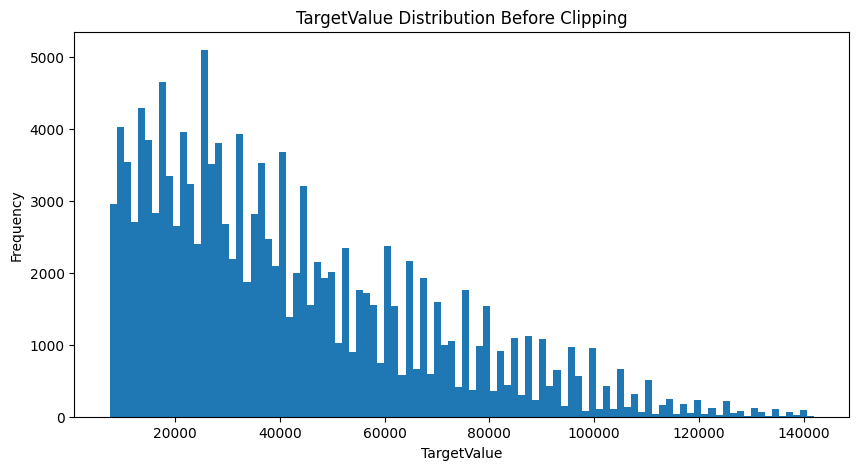

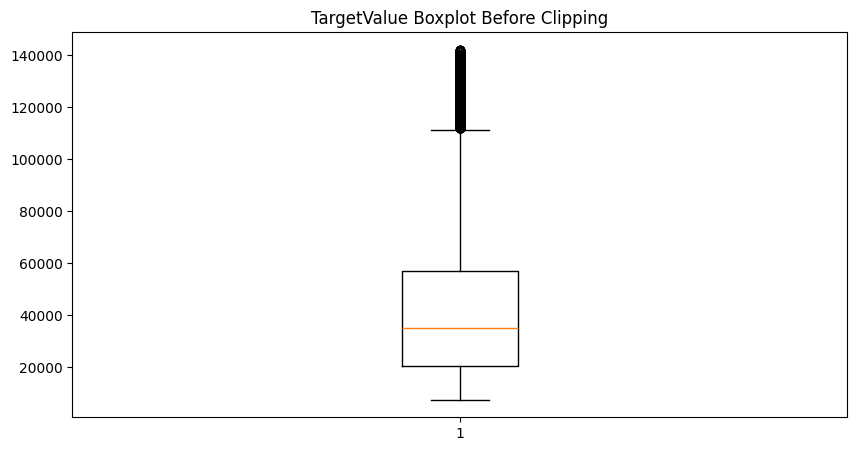

In [20]:
import matplotlib.pyplot as plt

# Target Distribution
plt.figure(figsize=(10,5))
plt.hist(train_data['TargetValue'], bins=100)
plt.title('TargetValue Distribution Before Clipping')
plt.xlabel('TargetValue')
plt.ylabel('Frequency')
plt.show()

# Boxplot
plt.figure(figsize=(10,5))
plt.boxplot(train_data['TargetValue'])
plt.title('TargetValue Boxplot Before Clipping')
plt.show()

In [21]:
numeric_cols = train_data.select_dtypes(
    include=['int64','float64']
).columns

exclude_cols = ['TransactionID','TargetValue']

for col in numeric_cols:

    if col not in exclude_cols:

        lower = train_data[col].quantile(0.01)
        upper = train_data[col].quantile(0.99)

        train_data[col] = train_data[col].clip(lower, upper)
        test_data[col] = test_data[col].clip(lower, upper)

# Clip Target

lower_target = train_data['TargetValue'].quantile(0.01)
upper_target = train_data['TargetValue'].quantile(0.99)

train_data['TargetValue'] = train_data['TargetValue'].clip(
    lower_target,
    upper_target
)

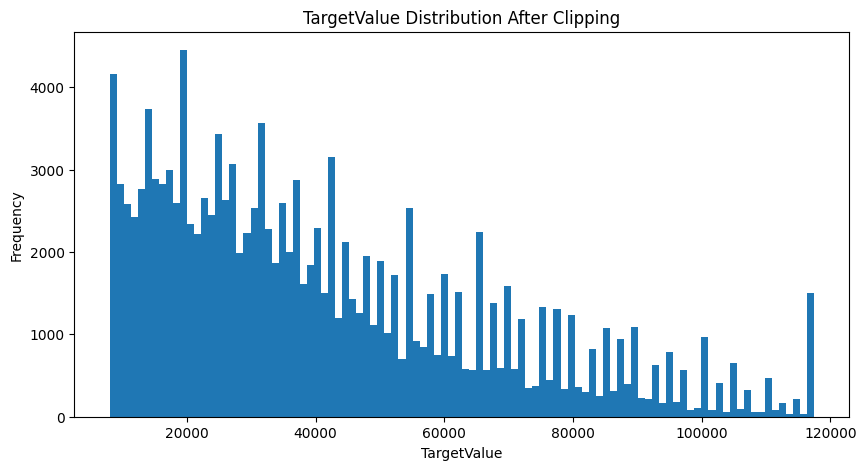

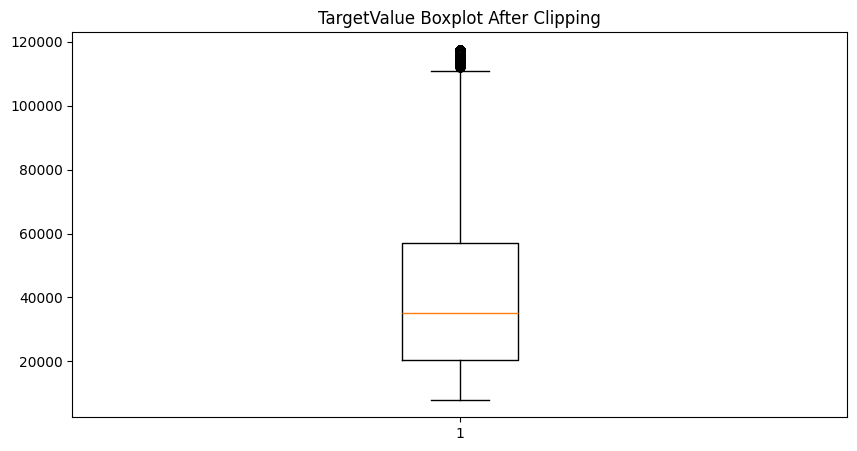

In [22]:
plt.figure(figsize=(10,5))
plt.hist(train_data['TargetValue'], bins=100)
plt.title('TargetValue Distribution After Clipping')
plt.xlabel('TargetValue')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10,5))
plt.boxplot(train_data['TargetValue'])
plt.title('TargetValue Boxplot After Clipping')
plt.show()

In [23]:
X_train.columns.tolist()

['AssetID',
 'ProductConfigID',
 'DataOriginCode',
 'VendorPartnerID',
 'ManufactureYear',
 'OperationalHoursMeter',
 'UtilizationTier',
 'Spec_FullDescriptor',
 'Spec_BaseClass',
 'Spec_SubClass',
 'Spec_ReleaseSeries',
 'Spec_VariantModifier',
 'AssetScaleFactor',
 'FunctionalClassification',
 'RegionCode',
 'InventoryGroupCategory',
 'InventoryGroupDescription',
 'col1',
 'CabinType',
 'Forks',
 'col3',
 'col4',
 'DrivetrainType',
 'col5',
 'col6',
 'col7',
 'col8',
 'col9',
 'col10',
 'col11',
 'col12',
 'col13',
 'col14',
 'col15',
 'col16',
 'col18',
 'col19',
 'col20',
 'col21',
 'col22',
 'col23',
 'col24',
 'col25',
 'col27',
 'col28',
 'col29',
 'col30',
 'saleYear',
 'saleMonth',
 'saleDay',
 'saleDayOfWeek',
 'AgeAtSale',
 'HoursPerYear']

In [24]:
train_data.columns.tolist()

['TransactionID',
 'TargetValue',
 'AssetID',
 'ProductConfigID',
 'DataOriginCode',
 'VendorPartnerID',
 'ManufactureYear',
 'OperationalHoursMeter',
 'UtilizationTier',
 'Spec_FullDescriptor',
 'Spec_BaseClass',
 'Spec_SubClass',
 'Spec_ReleaseSeries',
 'Spec_VariantModifier',
 'AssetScaleFactor',
 'FunctionalClassification',
 'RegionCode',
 'InventoryGroupCategory',
 'InventoryGroupDescription',
 'col1',
 'CabinType',
 'Forks',
 'col3',
 'col4',
 'DrivetrainType',
 'col5',
 'col6',
 'col7',
 'col8',
 'col9',
 'col10',
 'col11',
 'col12',
 'col13',
 'col14',
 'col15',
 'col16',
 'col18',
 'col19',
 'col20',
 'col21',
 'col22',
 'col23',
 'col24',
 'col25',
 'col27',
 'col28',
 'col29',
 'col30',
 'saleYear',
 'saleMonth',
 'saleDay',
 'saleDayOfWeek',
 'AgeAtSale',
 'HoursPerYear']

In [25]:
from sklearn.preprocessing import StandardScaler

# 1. Identify continuous numeric columns (AssetScaleFactor removed as it was label encoded)
numeric_cols = ['ManufactureYear', 'OperationalHoursMeter', 'AgeAtSale', 'HoursPerYear']

scaler = StandardScaler()

# 2. FIT and TRANSFORM on Training data only
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# 3. TRANSFORM ONLY on Validation and Test data
X_valid[numeric_cols] = scaler.transform(X_valid[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])  # Also fixed a typo here where X_valid was called twice!

In [26]:
# Identify the categorical columns by name
cat_features = train_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Ensure they are treated as string/category types (not numeric codes)
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [27]:
from catboost import CatBoostRegressor, Pool

# Create CatBoost Pools
train_pool = Pool(X_train, y_train, cat_features=cat_features)
val_pool = Pool(X_valid, y_valid, cat_features=cat_features)

# Initialize CatBoost
# Since heavy equipment prices can be highly skewed, 'RMSE' or 'MSLE' are great choices
model_cb = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100 # Prints log every 100 trees
)

# Train with early stopping
model_cb.fit(
    train_pool,
    eval_set=val_pool,
    early_stopping_rounds=50,
    use_best_model=True
)

0:	learn: 25655.9504063	test: 25491.9973071	best: 25491.9973071 (0)	total: 462ms	remaining: 11m 31s
100:	learn: 11625.0227449	test: 11338.2028383	best: 11338.2028383 (100)	total: 32.4s	remaining: 7m 28s
200:	learn: 10689.6119848	test: 10484.2334999	best: 10484.2334999 (200)	total: 1m 7s	remaining: 7m 14s
300:	learn: 10187.7781918	test: 10036.7491869	best: 10036.7491869 (300)	total: 1m 42s	remaining: 6m 48s
400:	learn: 9882.8858996	test: 9775.5173526	best: 9775.5173526 (400)	total: 2m 18s	remaining: 6m 19s
500:	learn: 9681.2436293	test: 9604.2856929	best: 9604.2856929 (500)	total: 2m 54s	remaining: 5m 47s
600:	learn: 9507.3838723	test: 9457.2120125	best: 9457.2120125 (600)	total: 3m 30s	remaining: 5m 14s
700:	learn: 9370.4217290	test: 9347.6898696	best: 9347.6898696 (700)	total: 4m 5s	remaining: 4m 40s
800:	learn: 9260.7368351	test: 9263.3491942	best: 9263.3491942 (800)	total: 4m 41s	remaining: 4m 5s
900:	learn: 9157.3208809	test: 9186.1458054	best: 9186.1458054 (900)	total: 5m 17s	rema

CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [28]:
from sklearn.metrics import root_mean_squared_log_error

# 1. Evaluate on Validation Set
val_preds = model_cb.predict(X_valid)
val_preds = np.clip(val_preds, 0, None) # Ensure no negative prices
rmsle = root_mean_squared_log_error(y_valid, val_preds)
print(f"CatBoost Validation RMSLE Score: {rmsle:.4f}")

# 2. Predict on Test Set
test_preds = model_cb.predict(X_test)
test_preds = np.clip(test_preds, 0, None)

# 3. Save Submission File
submission = pd.DataFrame({
    Id_col: test_data[Id_col],
    Target: test_preds
})
submission.to_csv("submission.csv", index=False)
print("Saved CatBoost predictions to submission.csv!")

CatBoost Validation RMSLE Score: 0.2425
Saved CatBoost predictions to submission.csv!
